IMPORT DATASET FOR BUSINESS UNDERSTANDING

Business Questions for this Project

1. Who is committing fraud?
2. When does fraud happen?
3. What transactio patterns indicate fraud?
4. How can financial institutions reduce losses?

In [1]:
import pandas as pd
import numpy as np

In [2]:
credit_fraud = pd.read_csv('../data/credit_card_fraud_dataset.csv')
credit_fraud.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [3]:
credit_fraud.shape

(100000, 7)

The dataset contains 100,000 rows and 7 columns, namely transaction ID, transaction date, amount, merchant ID, transaction type, location, and the binary indication if th transaction is fraudulent or not. Because of the size of this dataset, we deduce that it is large enough to carry out ML.

In [9]:
credit_fraud["TransactionDate"] = pd.to_datetime(credit_fraud["TransactionDate"])

In [10]:
credit_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[ns]
 2   Amount           100000 non-null  float64       
 3   MerchantID       100000 non-null  int64         
 4   TransactionType  100000 non-null  object        
 5   Location         100000 non-null  object        
 6   IsFraud          100000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 5.3+ MB


This indicates that there are 2 varibles that are categorical (transaction type and location), the rest are numerical. The variable transaction date is a variable that will be used for time series analysis. There are no missing values.

In [5]:
credit_fraud.describe()

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


Observations made:
1. The count row shows that all variables have 100,000 rows. This means that there are no missing values.
2. The mean and percentile values of transaction ID indicate that this variable is a sequential identifier rather than a real numeric signal.
3. The descriptive values of merchant ID shows uniform distribution across all the merchant ID values in the dataset.
4. Under the amount variable, there is substantial spread, but no extreme outliers beyond the dataset's max value. And because the median is close to the mean, this suggests a fairly balanced numeric distribution.
5. Because the mean of the variable IsFraud is 0.01, the transactions in the dataset are about 1% fraudulent, meaning the dataset is highly imbalanced. Thus fraud is quite rare. This will require a careful modeling strategy.

In [11]:
credit_fraud.duplicated().sum()

np.int64(0)

No duplicated values!

FRAUD CLASS ANALYSIS

Fraud datasets are usually imbalanced. Normal transactions can be 99% non-fraudulent, and 1% fraudulent. A simple model built for detection can be 99% accurate and still be useless.

In [6]:
credit_fraud['IsFraud'].value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

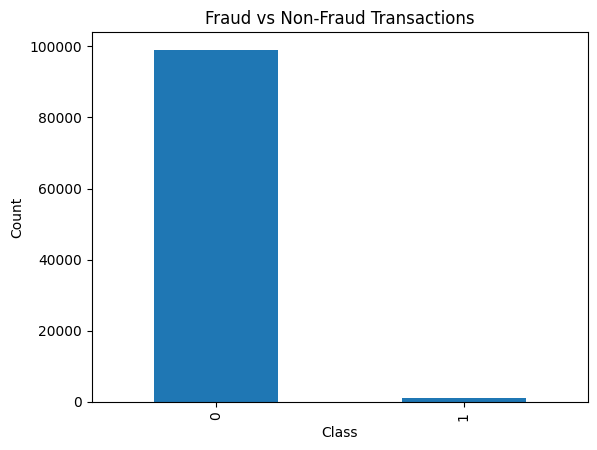

In [7]:
import matplotlib.pyplot as plt

credit_fraud['IsFraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()